In [95]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, confusion_matrix,
                             classification_report)


reading the data

In [96]:
df = pd.read_csv('Salaries.csv')
print(df.columns)

Index(['Id', 'EmployeeName', 'JobTitle', 'BasePay', 'OvertimePay', 'OtherPay',
       'Benefits', 'TotalPay', 'TotalPayBenefits', 'Year', 'Notes', 'Agency',
       'Status'],
      dtype='str')


C:\Users\romma\AppData\Local\Temp\ipykernel_28784\2501111161.py:1: DtypeWarning: Columns (0: BasePay, 1: OvertimePay, 2: OtherPay, 3: Benefits, 4: Status) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Salaries.csv')


get some primary info

In [97]:
print(df.columns)
print(len(df))
print(df['JobTitle'].value_counts())
print(df.isnull().sum().sort_values(ascending=False))
print(df.info())

Index(['Id', 'EmployeeName', 'JobTitle', 'BasePay', 'OvertimePay', 'OtherPay',
       'Benefits', 'TotalPay', 'TotalPayBenefits', 'Year', 'Notes', 'Agency',
       'Status'],
      dtype='str')
148654
JobTitle
Transit Operator                  7036
Special Nurse                     4389
Registered Nurse                  3736
Public Svc Aide-Public Works      2518
Police Officer 3                  2421
                                  ... 
Marina Associate Manager             1
Sr Cnselor, Juv Hall (SFERS)         1
Forensic Toxicologist Supervis       1
Conversion                           1
Cashier 3                            1
Name: count, Length: 2159, dtype: int64
Notes               148654
Status              110535
Benefits             36159
BasePay                605
Id                       0
OvertimePay              0
JobTitle                 0
EmployeeName             0
OtherPay                 0
TotalPayBenefits         0
TotalPay                 0
Year                    

It seems that there are nons in notes (all most all) , Benefits (big problem) , Basepay (very big problem)

some primary cleaning and handling

In [98]:
df.drop(columns='Notes',inplace=True)
cols = [
    'BasePay',
    'OvertimePay',
    'OtherPay',
    'Benefits',
    'TotalPay',
    'TotalPayBenefits'
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


Agency issue

In [99]:
agency = df['Agency'].value_counts()
print(f'ALL THE EMPLOYEES CAME FROM THE SAME AGENCY {agency}')

ALL THE EMPLOYEES CAME FROM THE SAME AGENCY Agency
San Francisco    148654
Name: count, dtype: int64


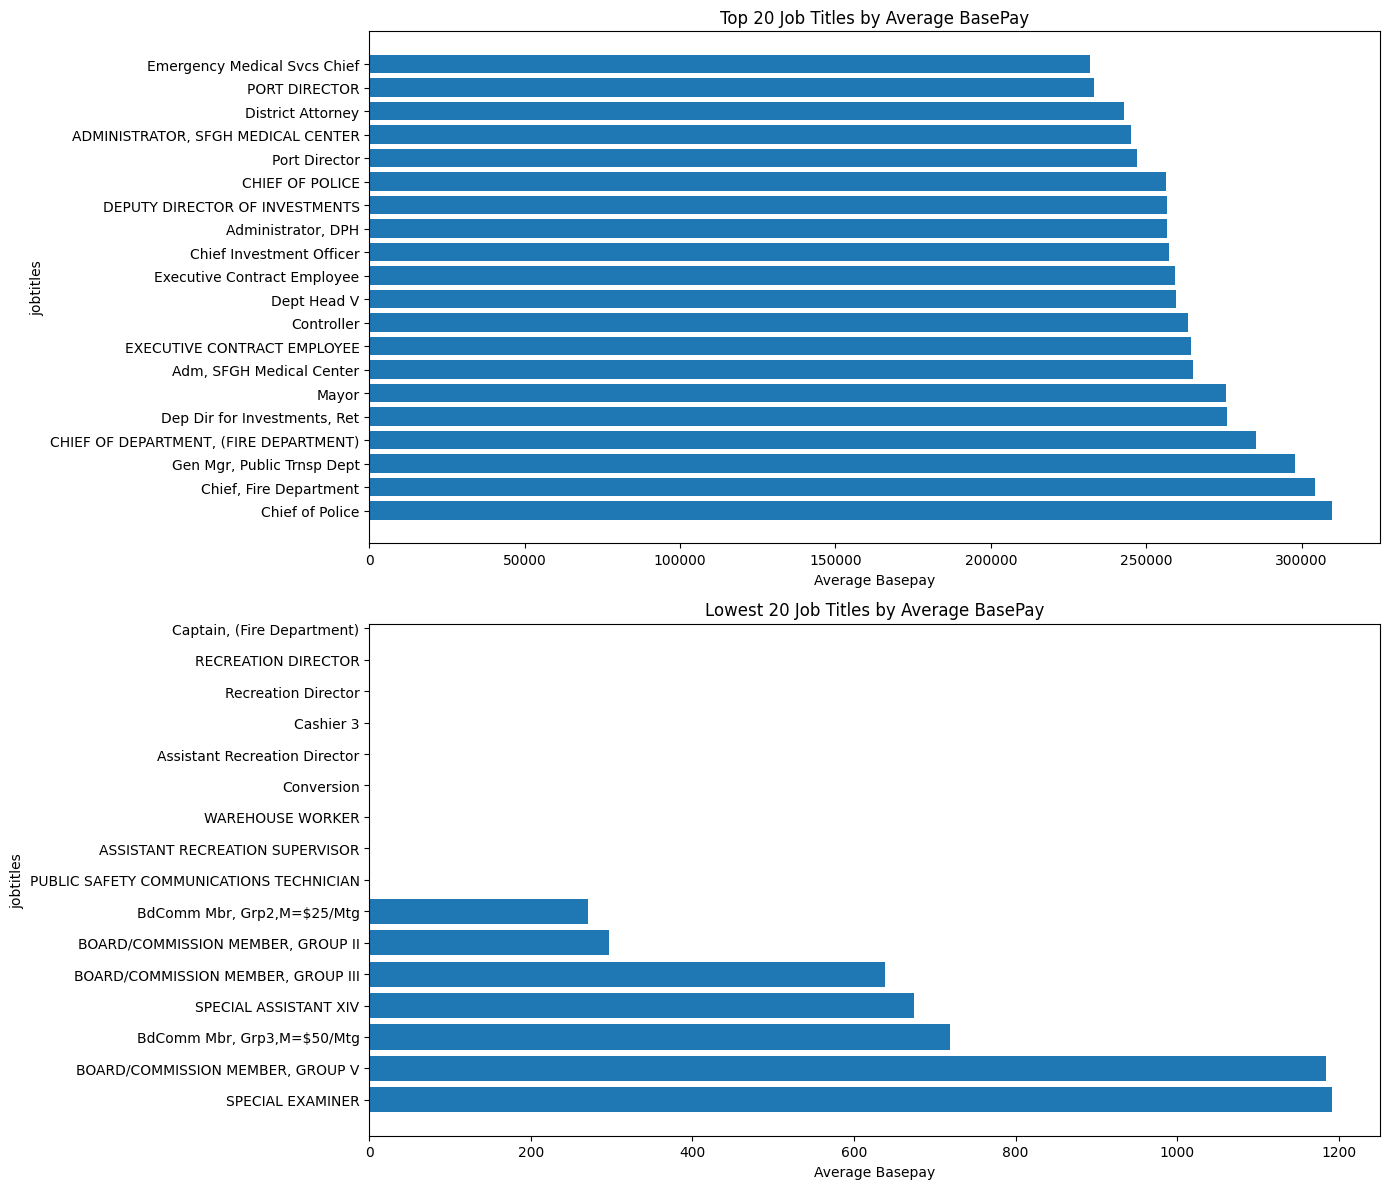

In [100]:
fig , axes = plt.subplots(2,1,figsize=(14,12))
job_bp_high= df.groupby('JobTitle')['BasePay'].mean().sort_values(ascending=False).head(20)
job_bp_low= df.groupby('JobTitle')['BasePay'].mean().sort_values(ascending=False).tail(20)

axes[0].barh(job_bp_high.index,job_bp_high.values)
axes[1].barh(job_bp_low.index,job_bp_low.values)
axes[0].set_ylabel('jobtitles')
axes[0].set_xlabel('Average Basepay')
axes[1].set_ylabel('jobtitles')
axes[1].set_xlabel('Average Basepay')
axes[0].set_title('Top 20 Job Titles by Average BasePay')
axes[1].set_title('Lowest 20 Job Titles by Average BasePay')

plt.tight_layout()


Text(0.5, 1.0, 'Progres of BasePay amoung years')

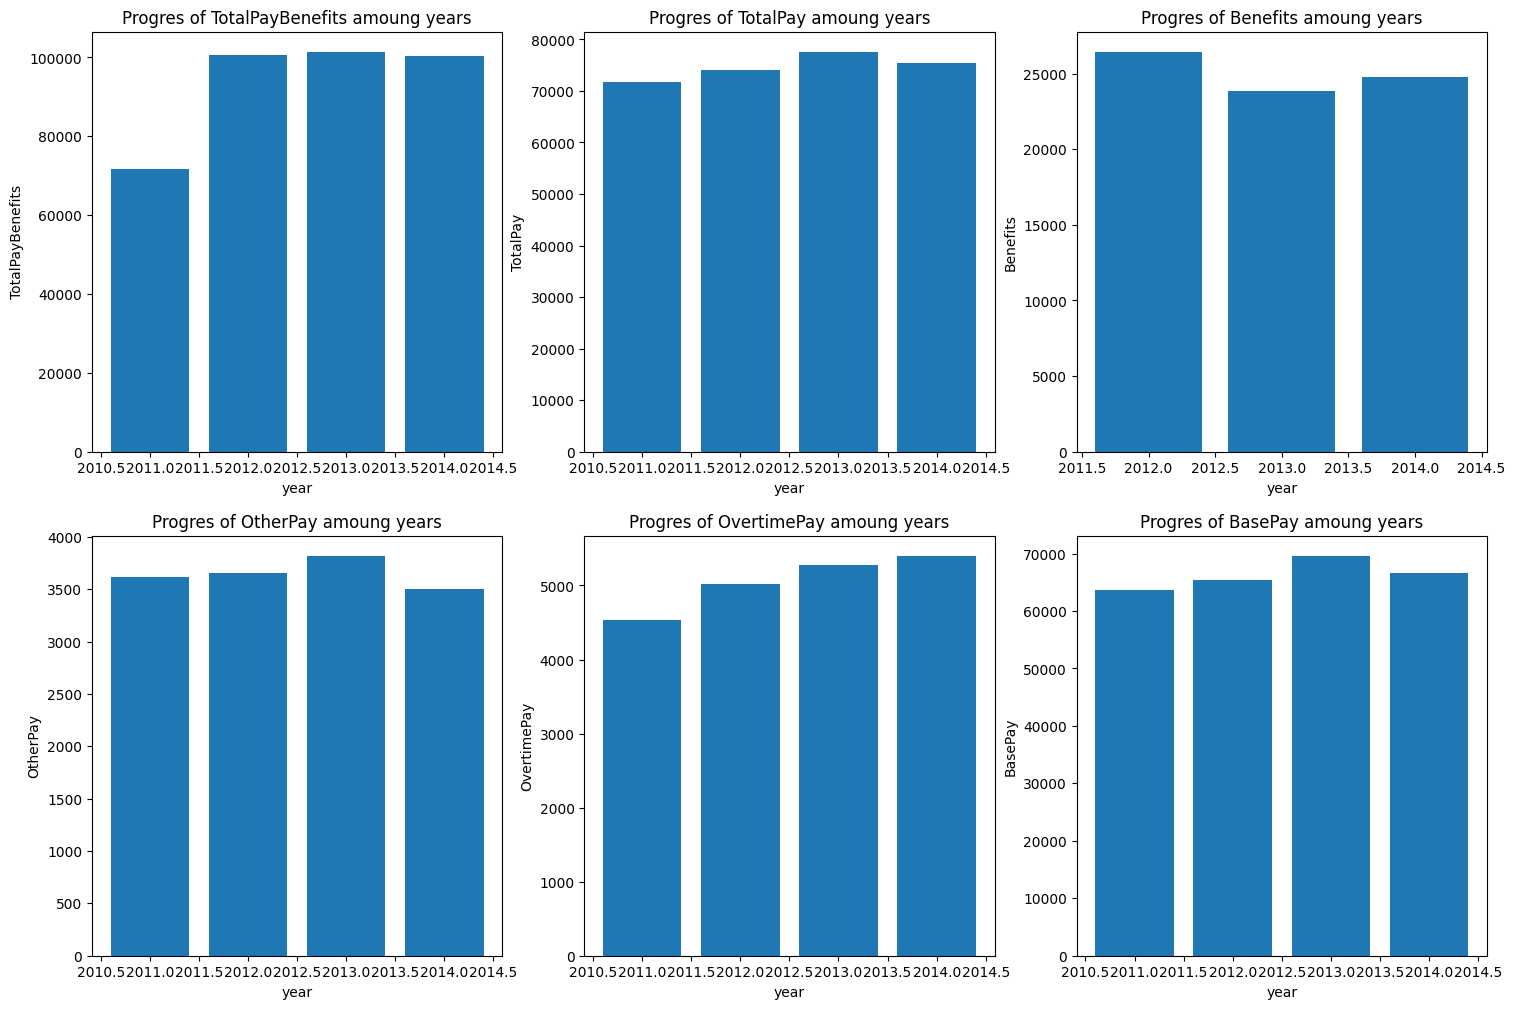

In [101]:
fig , axes = plt.subplots(2,3,figsize=(18,12))

total_ben_yearly = df.groupby('Year')['TotalPayBenefits'].mean()
axes[0,0].bar(total_ben_yearly.index,total_ben_yearly.values)
axes[0,0].set_xlabel('year')
axes[0,0].set_ylabel('TotalPayBenefits')
axes[0,0].set_title('Progres of TotalPayBenefits amoung years')

total_TotalPay_yearly = df.groupby('Year')['TotalPay'].mean()
axes[0,1].bar(total_TotalPay_yearly.index,total_TotalPay_yearly.values)
axes[0,1].set_xlabel('year')
axes[0,1].set_ylabel('TotalPay')
axes[0,1].set_title('Progres of TotalPay amoung years')

totalBenefits_yearly = df.groupby('Year')['Benefits'].mean()
axes[0,2].bar(totalBenefits_yearly.index,totalBenefits_yearly.values)
axes[0,2].set_xlabel('year')
axes[0,2].set_ylabel('Benefits')
axes[0,2].set_title('Progres of Benefits amoung years')


total_OtherPay_yearly = df.groupby('Year')['OtherPay'].mean()
axes[1,0].bar(total_OtherPay_yearly.index,total_OtherPay_yearly.values)
axes[1,0].set_xlabel('year')
axes[1,0].set_ylabel('OtherPay')
axes[1,0].set_title('Progres of OtherPay amoung years')

total_OvertimePay_yearly = df.groupby('Year')['OvertimePay'].mean()
axes[1,1].bar(total_OvertimePay_yearly.index,total_OvertimePay_yearly.values)
axes[1,1].set_xlabel('year')
axes[1,1].set_ylabel('OvertimePay')
axes[1,1].set_title('Progres of OvertimePay amoung years')

total_BasePay_yearly = df.groupby('Year')['BasePay'].mean()
axes[1,2].bar(total_BasePay_yearly.index,total_BasePay_yearly.values)
axes[1,2].set_xlabel('year')
axes[1,2].set_ylabel('BasePay')
axes[1,2].set_title('Progres of BasePay amoung years')

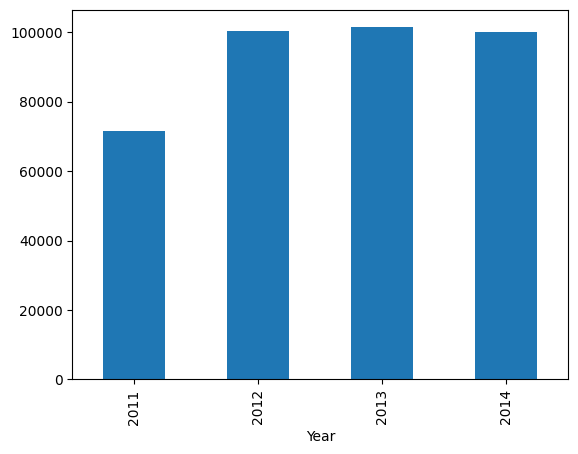

In [102]:
total_ben_yearly = df.groupby('Year')['TotalPayBenefits'].mean()
total_ben_yearly.plot(kind='bar')
plt.show()

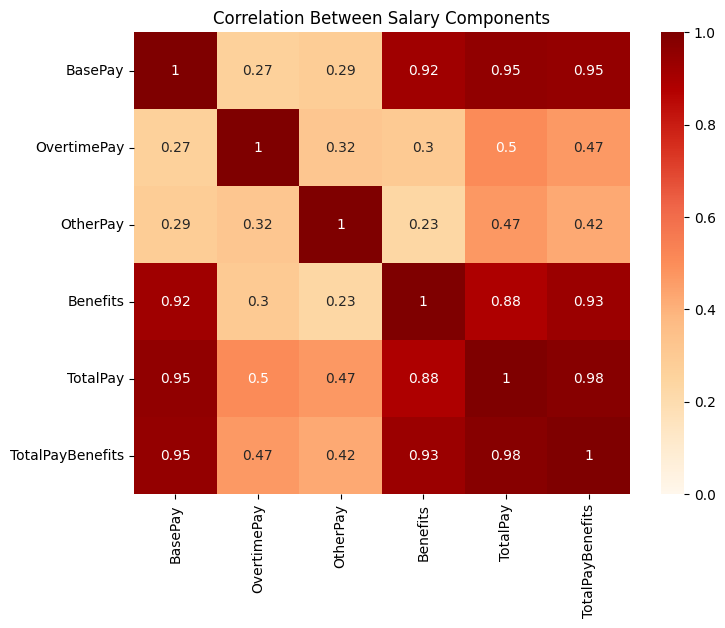

In [103]:
sal_comp = df[
    ['BasePay','OvertimePay','OtherPay',
     'Benefits','TotalPay','TotalPayBenefits']
]

corr_matrix = sal_comp.corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='OrRd',
    vmin=0,
    vmax=1
)
plt.title("Correlation Between Salary Components")
plt.show()



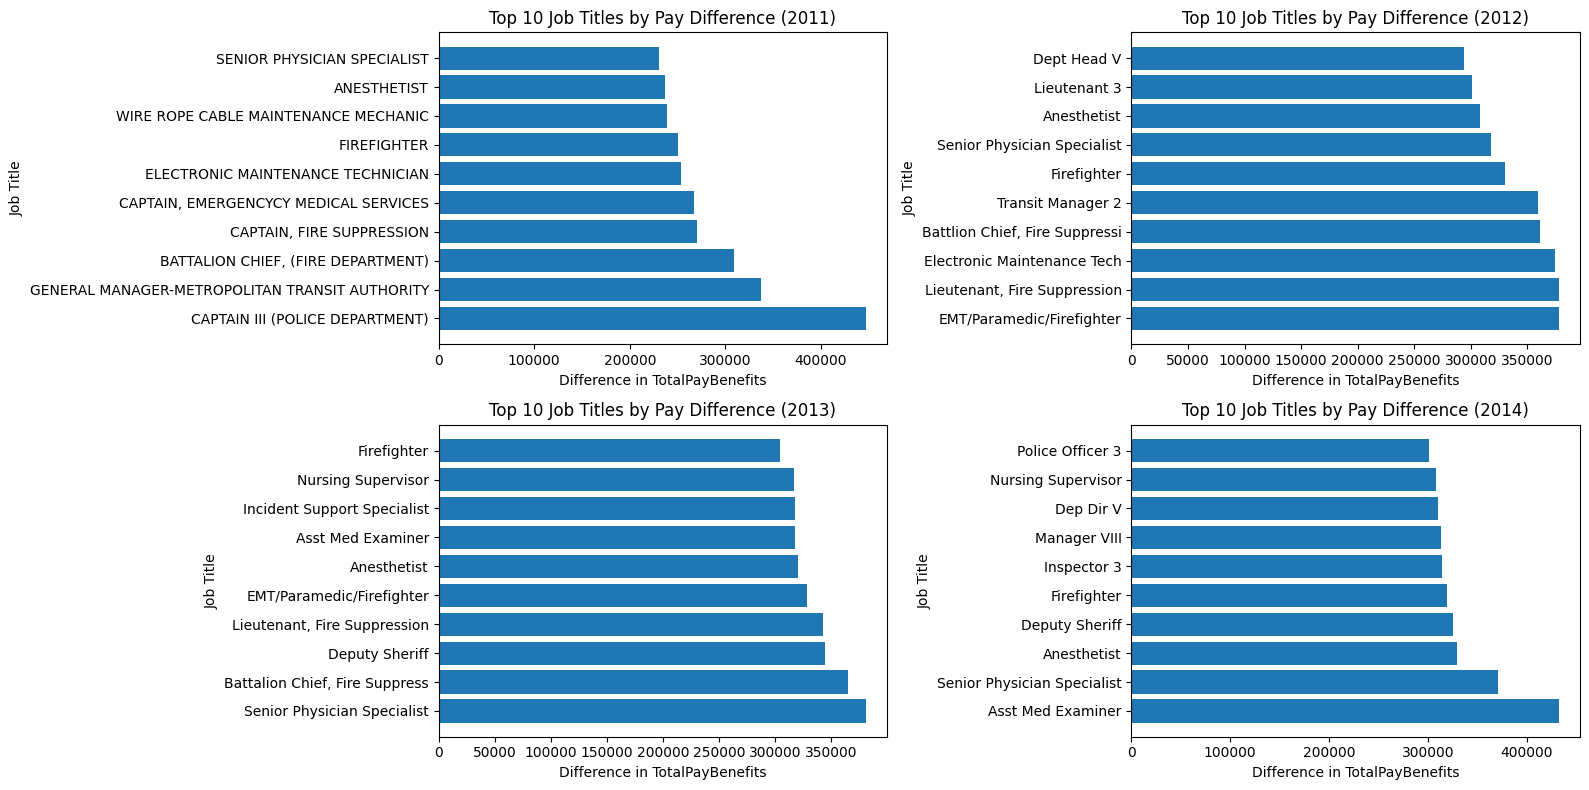

In [104]:
fig , axes = plt.subplots(2, 2, figsize=(16,8))

y14 = (
    df[df['Year'] == 2014]
    .groupby('JobTitle')['TotalPayBenefits']
    .agg(['max', 'min']))
y14['difference13'] = y14['max'] - y14['min']
y14 = y14.sort_values(by='difference13', ascending=False).head(10)
y13 = (
    df[df['Year'] == 2013]
    .groupby('JobTitle')['TotalPayBenefits']
    .agg(['max', 'min']))
y13['difference13'] = y13['max'] - y13['min']
y13 = y13.sort_values(by='difference13', ascending=False).head(10)
y12 = (
    df[df['Year'] == 2012]
    .groupby('JobTitle')['TotalPayBenefits']
    .agg(['max', 'min'])
)
y12['difference12'] = y12['max'] - y12['min']
y12 = y12.sort_values(by='difference12', ascending=False).head(10)
y11 = (
    df[df['Year'] == 2011]
    .groupby('JobTitle')['TotalPayBenefits']
    .agg(['max', 'min'])
)
y11['difference'] = y11['max'] - y11['min']
y11 = y11.sort_values(by='difference', ascending=False).head(10)

axes[0,0].barh(y11.index, y11['difference'])
axes[0,0].set_xlabel('Difference in TotalPayBenefits')
axes[0,0].set_ylabel('Job Title')
axes[0,0].set_title('Top 10 Job Titles by Pay Difference (2011)')

axes[0,1].barh(y12.index, y12['difference12'])
axes[0,1].set_xlabel('Difference in TotalPayBenefits')
axes[0,1].set_ylabel('Job Title')
axes[0,1].set_title('Top 10 Job Titles by Pay Difference (2012)')

axes[1,0].barh(y13.index, y13['difference13'])
axes[1,0].set_xlabel('Difference in TotalPayBenefits')
axes[1,0].set_ylabel('Job Title')
axes[1,0].set_title('Top 10 Job Titles by Pay Difference (2013)')

axes[1,1].barh(y14.index, y14['difference13'])
axes[1,1].set_xlabel('Difference in TotalPayBenefits')
axes[1,1].set_ylabel('Job Title')
axes[1,1].set_title('Top 10 Job Titles by Pay Difference (2014)')
plt.tight_layout()

In [105]:
agency = df['Agency'].value_counts()
print(f'ALL THE EMPLOYEES CAME FROM THE SAME AGENCY {agency}') 

ALL THE EMPLOYEES CAME FROM THE SAME AGENCY Agency
San Francisco    148654
Name: count, dtype: int64


we must varieties our sources

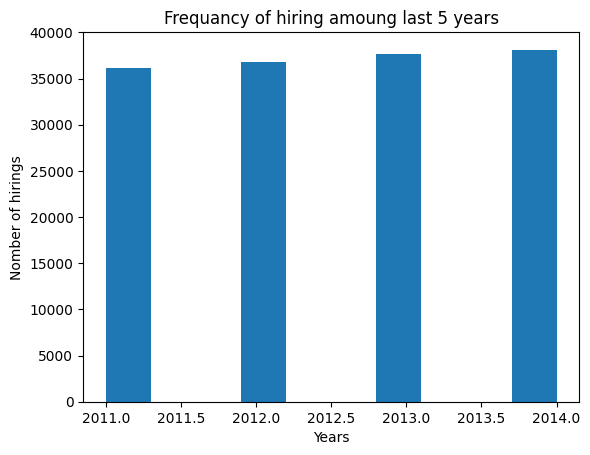

In [106]:
plt.hist(df.Year)
plt.xlabel('Years')
plt.ylabel('Nomber of hirings')
plt.title('Frequancy of hiring amoung last 5 years')
plt.show()

In [107]:

no_ofnulls = df.isnull().sum()
print(((no_ofnulls/len(df))*100).round(2))
df.drop(columns='Status',inplace=True) #drop satatus feature

Id                   0.00
EmployeeName         0.00
JobTitle             0.00
BasePay              0.41
OvertimePay          0.00
OtherPay             0.00
Benefits            24.33
TotalPay             0.00
TotalPayBenefits     0.00
Year                 0.00
Agency               0.00
Status              74.36
dtype: float64


In [108]:
BP_matrix = df.groupby('JobTitle')['BasePay'].agg(BPM='mean' , BPMD = 'median',BPMNS= lambda x : x.isnull().sum() , BPMC='count').reset_index()
BP_matrix['BPNP']=(BP_matrix['BPMNS']/(BP_matrix['BPMC']+BP_matrix['BPMNS']))*100
BP_matrix['BP'] = np.zeros(len(BP_matrix))
BP_matrix['BP'] = np.where((BP_matrix['BPNP']<=25)&(BP_matrix['BPM']==BP_matrix['BPMD']),BP_matrix['BPM'],BP_matrix['BP'])
BP_matrix['BP']= np.where((BP_matrix['BPNP']<=25)&(BP_matrix['BPM']!=BP_matrix['BPMD']),BP_matrix['BPMD'],BP_matrix['BP'])
BP_matrix = BP_matrix[BP_matrix['BPNP'] <= 25]
df = pd.merge(df,BP_matrix,on='JobTitle',how= 'right')
df['BasePay'] = np.where(df['BasePay'].isnull(),df['BP'],df['BasePay'])
##df = df[(~df['Benefits'].isnull())&(df['Year']!=2011)] #if we decided to map year feature 


In [109]:

no_ofnulls = df.isnull().sum()
print(((no_ofnulls/len(df))*100).round(2))

Id                   0.00
EmployeeName         0.00
JobTitle             0.00
BasePay              0.00
OvertimePay          0.00
OtherPay             0.00
Benefits            24.34
TotalPay             0.00
TotalPayBenefits     0.00
Year                 0.00
Agency               0.00
BPM                  0.00
BPMD                 0.00
BPMNS                0.00
BPMC                 0.00
BPNP                 0.00
BP                   0.00
dtype: float64


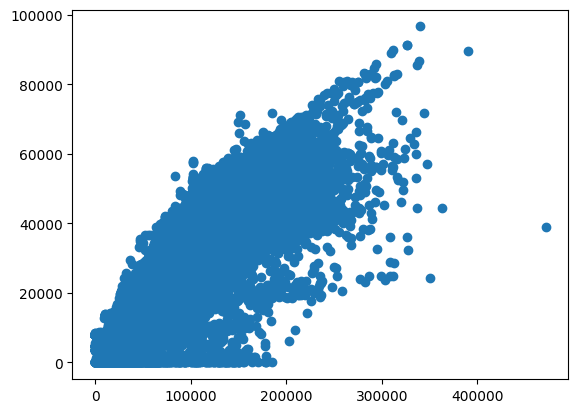

In [110]:
plt.scatter(df['TotalPay'],df['Benefits'])
plt.show()

The final check

##Knowing that : 
TotalPayBenefits = TotalPay + Benefits
TotalPayBenefits = BasePay + OvertimePay + OtherPay + Benefits
Then the features will be : TotalPay , Benefits

In [111]:
reg = df[~df['Benefits'].isnull()].reset_index()
x_reg = reg[['TotalPay']]
y_reg = reg[['Benefits']]
x_train , x_test , y_train , y_test = train_test_split(x_reg,y_reg,train_size=0.8,test_size=0.2,random_state=42)
scaler = StandardScaler()
x_train_scaled =scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
ml = LinearRegression()
ml.fit(x_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


50820436.23717492 7128.845364936381 0.7832722527199081


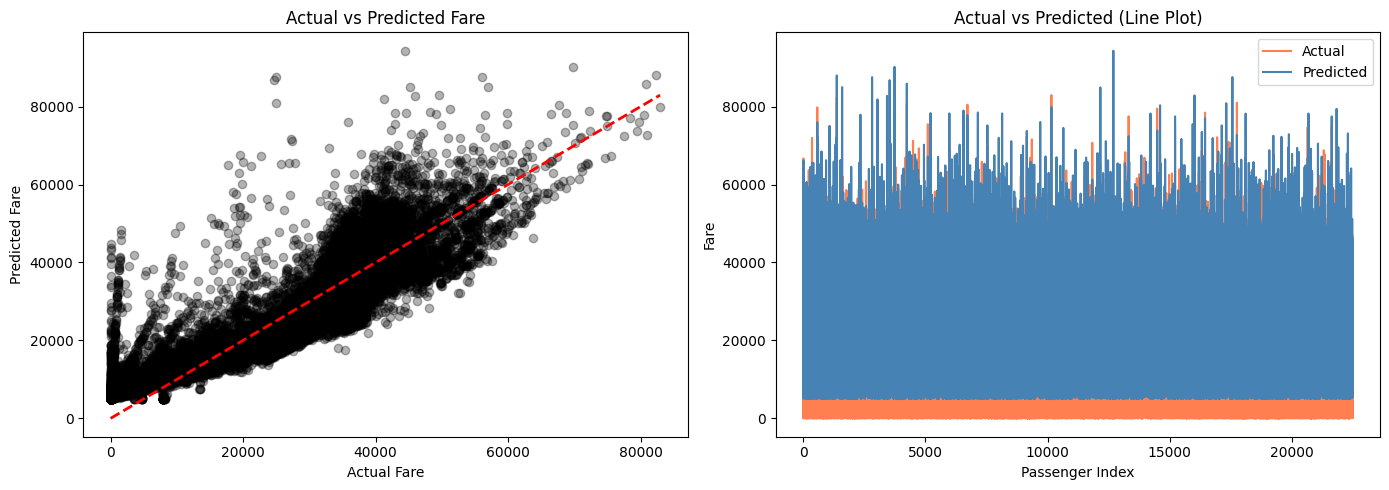

In [112]:
y_pred = ml.predict(x_test_scaled)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
print(mse,rmse,r2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, color='black', alpha=0.3)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted Fare')
axes[0].set_xlabel('Actual Fare')
axes[0].set_ylabel('Predicted Fare')

axes[1].plot(range(len(y_test)), y_test.values, label='Actual', color='coral')
axes[1].plot(range(len(y_pred)), y_pred, label='Predicted', color='steelblue')
axes[1].set_title('Actual vs Predicted (Line Plot)')
axes[1].set_xlabel('Passenger Index')
axes[1].set_ylabel('Fare')
axes[1].legend()

plt.tight_layout()

MSE: 33208890.147108234
RMSE: 5762.715518495445
R2: 0.8583780761411484


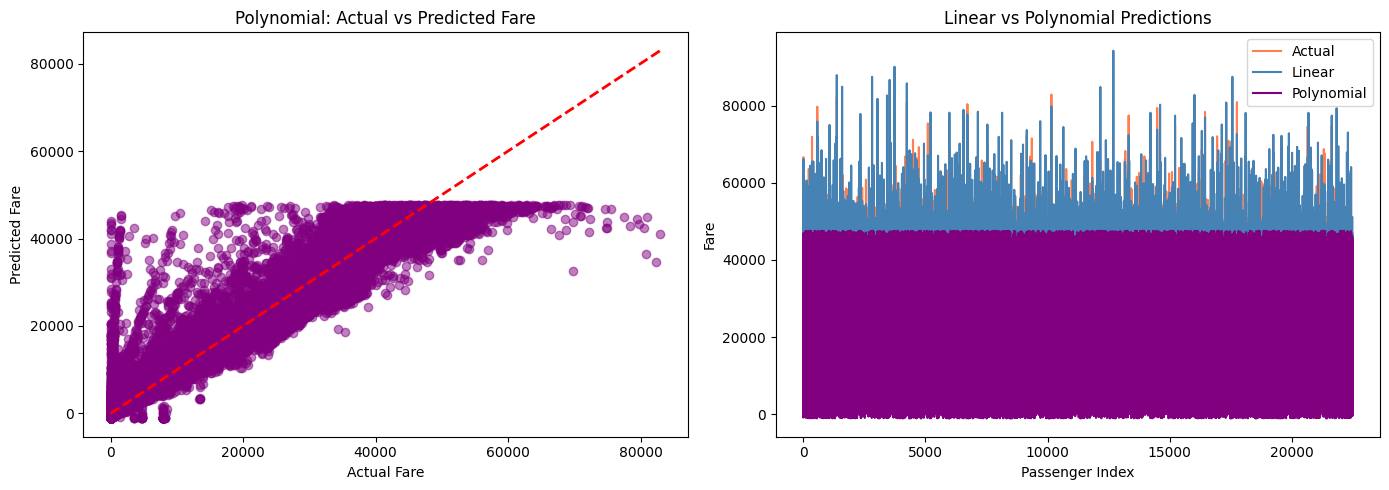

In [113]:

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(x_train)  
X_test_poly  = poly.transform(x_test)       


poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)


y_pred_poly = poly_model.predict(X_test_poly)

mse_poly  = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly   = r2_score(y_test, y_pred_poly)

print("MSE:", mse_poly)
print("RMSE:", rmse_poly)
print("R2:", r2_poly)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_poly, color='purple', alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Polynomial: Actual vs Predicted Fare')
axes[0].set_xlabel('Actual Fare')
axes[0].set_ylabel('Predicted Fare')

axes[1].plot(range(len(y_test)), y_test.values, label='Actual',     color='coral')
axes[1].plot(range(len(y_pred)),  y_pred,         label='Linear',     color='steelblue')
axes[1].plot(range(len(y_pred_poly)),y_pred_poly,        label='Polynomial', color='purple')
axes[1].set_title('Linear vs Polynomial Predictions')
axes[1].set_xlabel('Passenger Index')
axes[1].set_ylabel('Fare')
axes[1].legend()

plt.tight_layout()

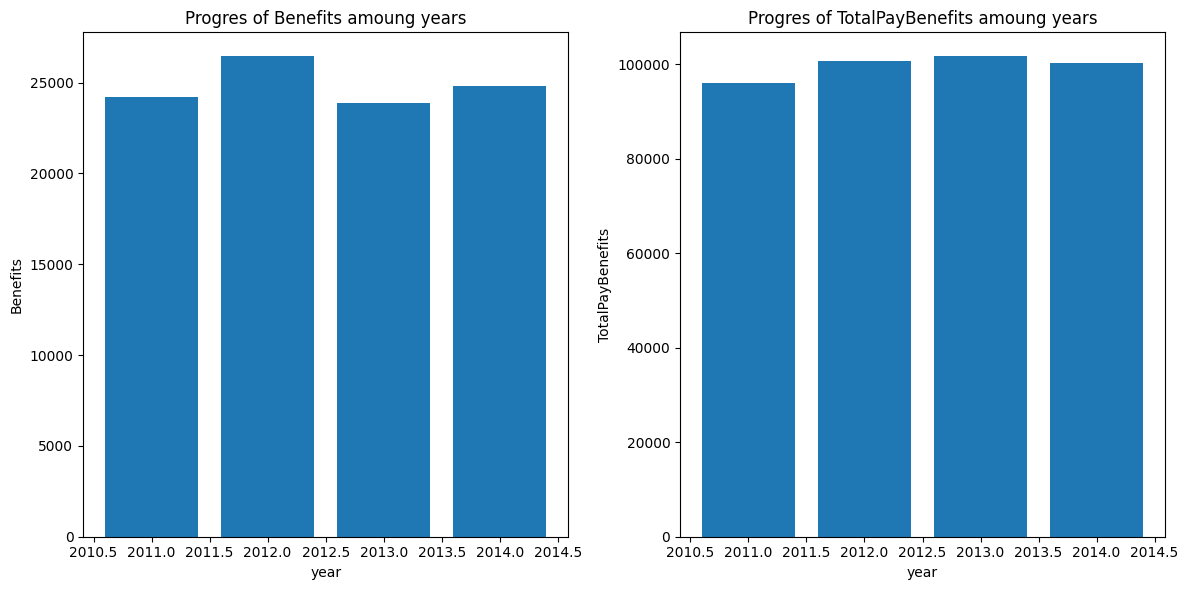

In [114]:
total_2011 = df.loc[df['Year'] == 2011, ['Id', 'TotalPay']].reset_index()
X_2011_poly = poly.transform(total_2011[['TotalPay']])
ben_predict = poly_model.predict(X_2011_poly)
total_2011['prediction']=ben_predict
df = pd.merge(df,total_2011,on='Id',how='left')
df['Benefits']=np.where((df['Year']==2011)&(df['Benefits'].isnull()),df['prediction'],df['Benefits'])

df['TotalPayBenefits'] = df['Benefits'] + df['TotalPay_x']

fig , axes = plt.subplots(1,2,figsize=(12,6))

totalBenefits_yearly = df.groupby('Year')['Benefits'].mean()
axes[0].bar(totalBenefits_yearly.index,totalBenefits_yearly.values)
axes[0].set_xlabel('year')
axes[0].set_ylabel('Benefits')
axes[0].set_title('Progres of Benefits amoung years')

total_TotalPay_yearly = df.groupby('Year')['TotalPayBenefits'].mean()
axes[1].bar(total_TotalPay_yearly.index,total_TotalPay_yearly.values)
axes[1].set_xlabel('year')
axes[1].set_ylabel('TotalPayBenefits')
axes[1].set_title('Progres of TotalPayBenefits amoung years')

plt.tight_layout()

In [115]:
df = df.drop(columns={'BPM'                  
,'BPMD'                 
,'BPMNS'                
,'BPMC'                 
,'BPNP'                 
,'BP'                   
,'index'               
,'TotalPay_y'          
,'prediction' })

no_ofnulls = df.isnull().sum()
print(((no_ofnulls/len(df))*100).round(2))
display(df)

Id                  0.0
EmployeeName        0.0
JobTitle            0.0
BasePay             0.0
OvertimePay         0.0
OtherPay            0.0
Benefits            0.0
TotalPay_x          0.0
TotalPayBenefits    0.0
Year                0.0
Agency              0.0
dtype: float64


,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay_x,TotalPayBenefits,Year,Agency
0,20766,NAPOLEON VIRAY,ACCOUNT CLERK,60838.20,0.00,0.00,23313.817207,60838.20,84152.017207,2011,San Francisco
1,20868,BERNADETTE RAMOS,ACCOUNT CLERK,49777.81,10753.06,0.00,23211.555470,60530.87,83742.425470,2011,San Francisco
2,21639,SUSAN CHANG,ACCOUNT CLERK,51306.28,5406.34,1814.58,22539.578134,58527.20,81066.778134,2011,San Francisco
3,22973,OLIVIA BOUDREAUX,ACCOUNT CLERK,49778.15,3811.68,1084.76,21221.831561,54674.59,75896.421561,2011,San Francisco
4,24133,LI-XIN CAI,ACCOUNT CLERK,49777.80,1390.45,624.00,20213.857293,51792.25,72006.107293,2011,San Francisco
...,...,...,...,...,...,...,...,...,...,...,...
148526,58843,Mario Yedidia,Youth Comm Advisor,57544.73,0.00,0.00,28229.660000,57544.73,85774.390000,2012,San Francisco
148527,98075,Phimy Truong,Youth Comm Advisor,52433.88,0.00,0.00,25297.500000,52433.88,77731.380000,2013,San Francisco
148528,103334,Mario R Yedidia,Youth Comm Advisor,13915.80,0.00,5296.91,5744.530000,19212.71,24957.240000,2013,San Francisco
148529,138459,Phimy Truong,Youth Comm Advisor,32417.42,0.00,4048.49,15545.280000,36465.91,52011.190000,2014,San Francisco


Effect of PCA on Regression

sal_comp = reg[['BasePay','OvertimePay','OtherPay']]
std = StandardScaler()
sal_comp_std = std.fit_transform(sal_comp)
sal_cov = np.cov(sal_comp_std.T)

eigenvalues , eigenvectors = np.linalg.eigh(sal_cov)
sort_indices = np.argsort(eigenvalues)[::-1]
evr = eigenvalues / eigenvalues.sum()
evr_sorted = evr[sort_indices]
cum_evr_sorted = np.cumsum(evr_sorted)
display(cum_evr_sorted)
print(evr_sorted)

We will take pc1 and pc2 and pc3 only to keep 98% of variation of the data

T = sal_comp_std @ eigenvectors   

t = pd.DataFrame(
    T,
    columns=[f'PC{i+1}' for i in range(eigenvectors.shape[1])]
)

display(t)

lr = LinearRegression()
t = t[['PC1','PC2','PC3']]
pc_train , pc_test , pcy_train , pcy_test = train_test_split(t,y_reg,train_size=0.8,random_state=42)
reg_pca = lr.fit(pc_train,pcy_train)
pred_pca = reg_pca.predict(pc_test)
mse_pca  = mean_squared_error(pcy_test, pred_pca)
rmse_pca = np.sqrt(mse_pca).round(2)
display(mse_pca,rmse_pca)

Higher MSE than polynomial regression 

poly_pca = PolynomialFeatures(degree=2)
t = poly_pca.fit_transform(t)
pca_ptrain , pca_ptest , pcay_ptrain , pcay_ptest = train_test_split(t,y_reg,train_size=0.8,random_state=42)

lrp = LinearRegression()

poly_pca = lrp.fit(pca_ptrain,pcay_ptrain)
pred_poly_y = poly_pca.predict(pca_ptest)
poly_pca_mse = mean_squared_error(pcay_ptest,pred_poly_y)
r2_pca_poly = r2_score(pcay_ptest,pred_poly_y)
display(r2_pca_poly)
display(np.sqrt(poly_pca_mse))
display(poly_pca_mse)

In [ ]:
#Apply Hot one encoding on job titles
df = pd.get_dummies(df,columns=['JobTitle'], drop_first=True)

#Apply label encoding on year
df['Year'] = df['Year'].map({2011:1,2012:2,2013:3,2014:4})

#Prepare data for modeling
df_prepare = df.drop(columns=['Id','EmployeeName','TotalPay_x','Agency','TotalPayBenefits'])

display(df_prepare)

,BasePay,OvertimePay,OtherPay,Benefits,Year,JobTitle_ACCOUNTANT,JobTitle_ACCOUNTANT INTERN,"JobTitle_ACPO,JuvP, Juv Prob (SFERS)",JobTitle_ACUPUNCTURIST,JobTitle_ADMINISTRATIVE ANALYST,...,JobTitle_Window Cleaner Supervisor,JobTitle_Wire Rope Cable Maint Mechanic,JobTitle_Wire Rope Cable Maint Sprv,JobTitle_Worker's Comp Supervisor 1,JobTitle_Worker's Compensation Adjuster,JobTitle_X-RAY LABORATORY AIDE,JobTitle_X-Ray Laboratory Aide,"JobTitle_YOUTH COMMISSION ADVISOR, BOARD OF SUPERVISORS",JobTitle_Youth Comm Advisor,JobTitle_ZOO CURATOR
0,60838.20,0.00,0.00,23313.817207,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,49777.81,10753.06,0.00,23211.555470,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,51306.28,5406.34,1814.58,22539.578134,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,49778.15,3811.68,1084.76,21221.831561,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,49777.80,1390.45,624.00,20213.857293,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148526,57544.73,0.00,0.00,28229.660000,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
148527,52433.88,0.00,0.00,25297.500000,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
148528,13915.80,0.00,5296.91,5744.530000,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
148529,32417.42,0.00,4048.49,15545.280000,4,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


Apply polynomial regression to train a model for predicting the totale pay benfits

In [120]:
enc_stand = StandardScaler()

#Split the new data
x_train_enc , x_test_enc , y_train_enc , y_test_enc = train_test_split(df_prepare,df['TotalPayBenefits'],train_size=0.8,random_state=42)

#Polynomial standrization for the parameters
x_train_enc_stand = enc_stand.fit_transform(x_train_enc)
x_test_enc_stand = enc_stand.transform(x_test_enc)

#Intiating the model
lr_enc = LinearRegression()

#Traing of the model
lr_enc.fit(x_train_enc_stand,y_train_enc)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Checking the new model accuracy

In [121]:
#Make the frist prediction 
y_enc_pred = lr_enc.predict(x_test_enc_stand)

#Getting the MSE and RMSE
mse_enc = mean_squared_error(y_test_enc,y_enc_pred)
rmse_enc = np.sqrt(mse_enc)

#Getting the r2_score 
r2_enc = r2_score(y_test_enc,y_enc_pred)

#Displaying
display(mse_enc,rmse_enc,r2_enc)

16858796.580914367

np.float64(4105.946490264379)

0.9959705721102518